In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
df = sns.load_dataset("iris")

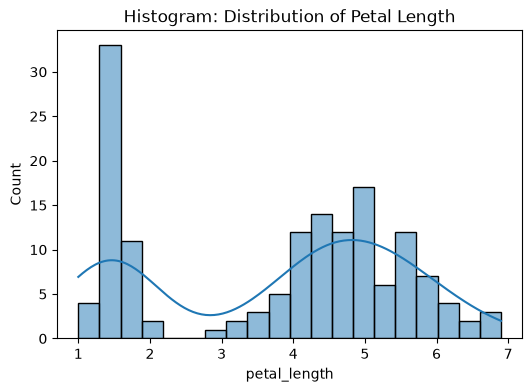

In [3]:
plt.figure(figsize=(6,4))
sns.histplot(df['petal_length'], bins=20, kde=True)
plt.title("Histogram: Distribution of Petal Length")
plt.show()

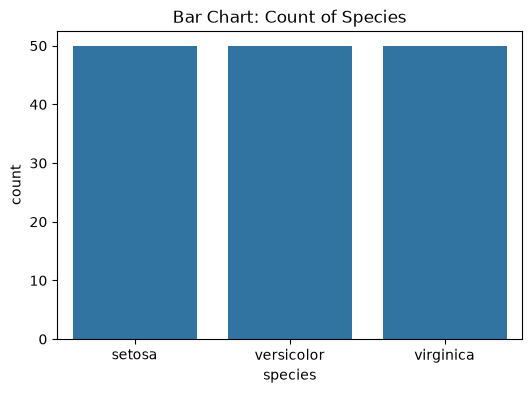

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df)
plt.title("Bar Chart: Count of Species")
plt.show()

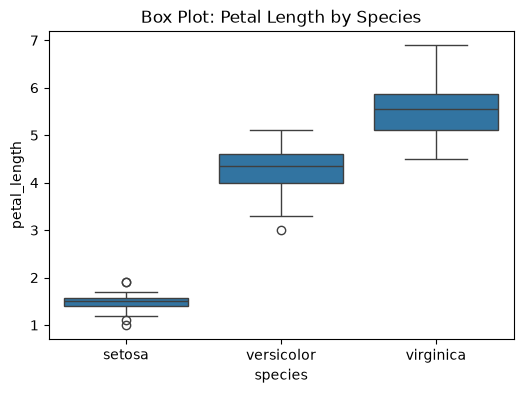

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(x="species", y="petal_length", data=df)
plt.title("Box Plot: Petal Length by Species")
plt.show()

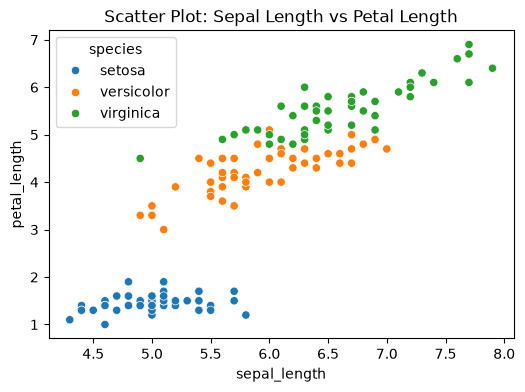

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=df)
plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.show()

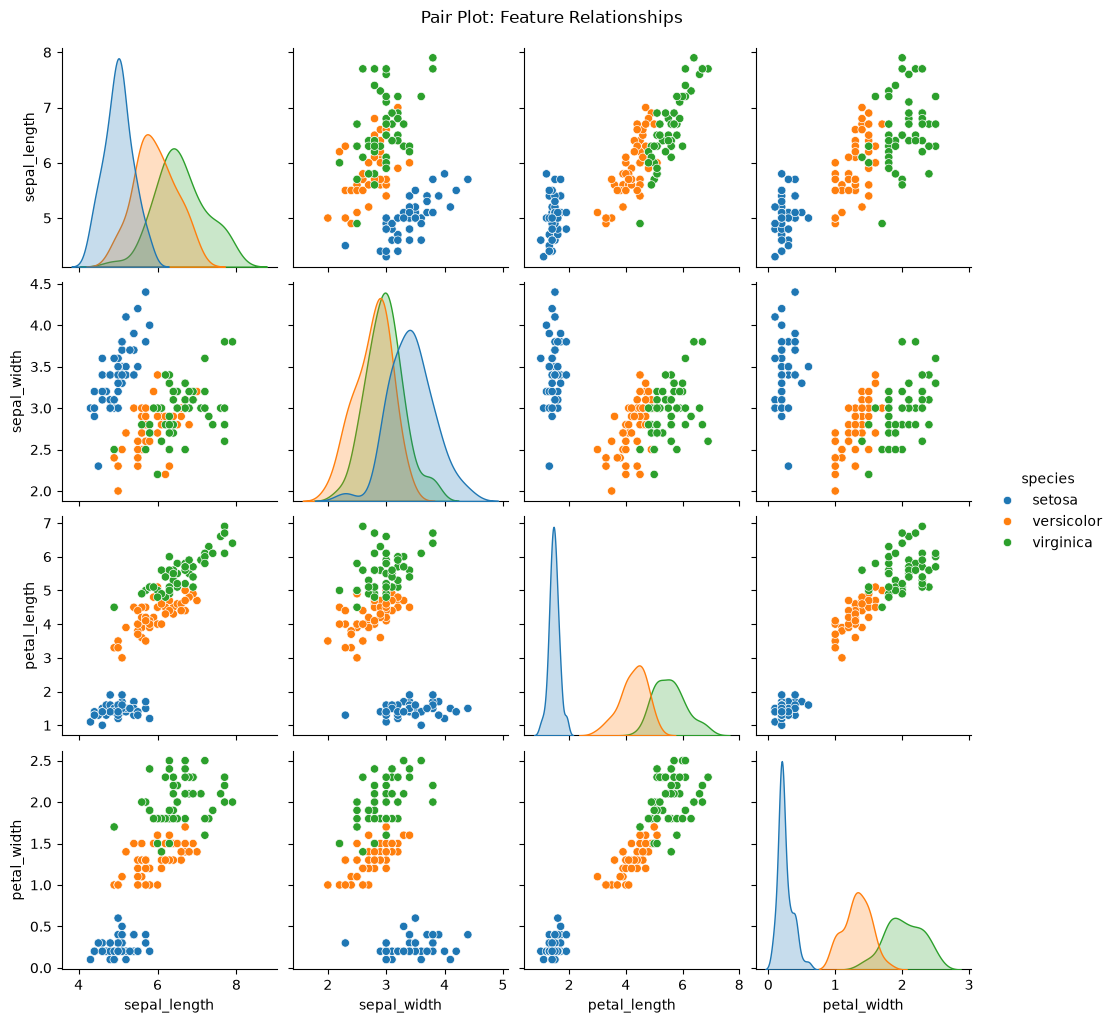

In [7]:
sns.pairplot(df, hue="species")
plt.suptitle("Pair Plot: Feature Relationships", y=1.02)
plt.show()

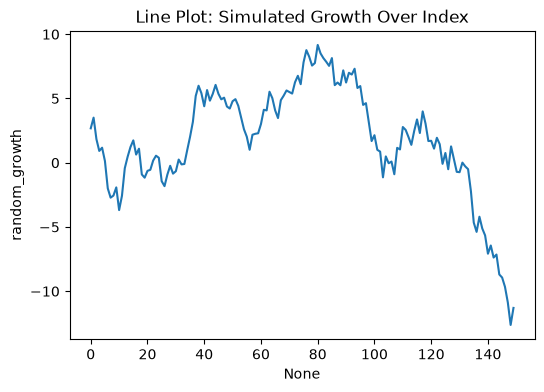

In [8]:
plt.figure(figsize=(6,4))
df["random_growth"] = np.random.randn(len(df)).cumsum()
sns.lineplot(x=df.index, y="random_growth", data=df)
plt.title("Line Plot: Simulated Growth Over Index")
plt.show()

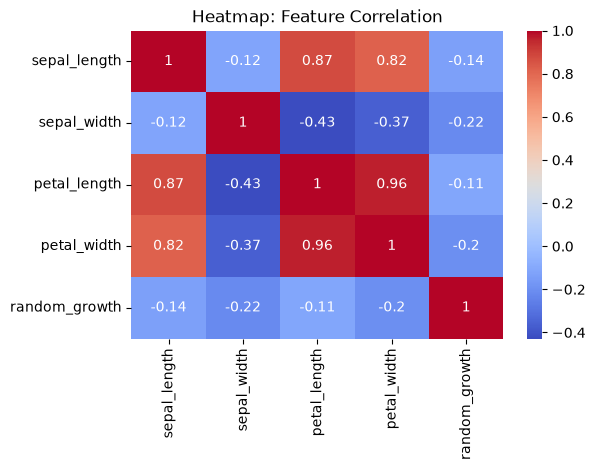

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap: Feature Correlation")
plt.show()

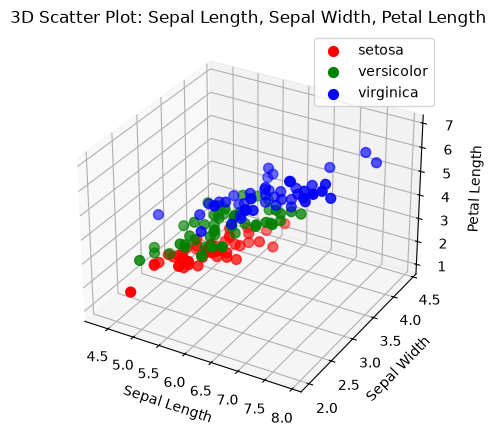

In [10]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")

species = df["species"].unique()
colors = ["r", "g", "b"]

for sp, col in zip(species, colors):
    subset = df[df["species"] == sp]
    ax.scatter(subset["sepal_length"],
               subset["sepal_width"],
               subset["petal_length"],
               c=col, label=sp, s=50)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("3D Scatter Plot: Sepal Length, Sepal Width, Petal Length")
ax.legend()

plt.show()

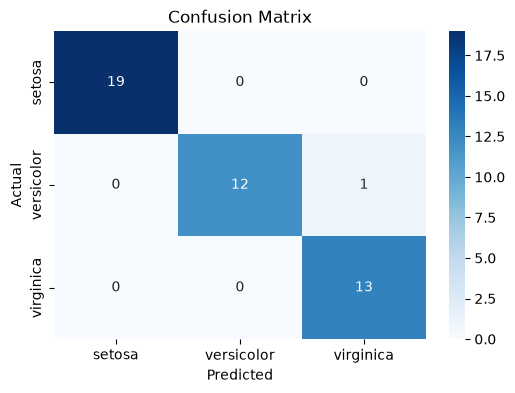

In [11]:
# Split data
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

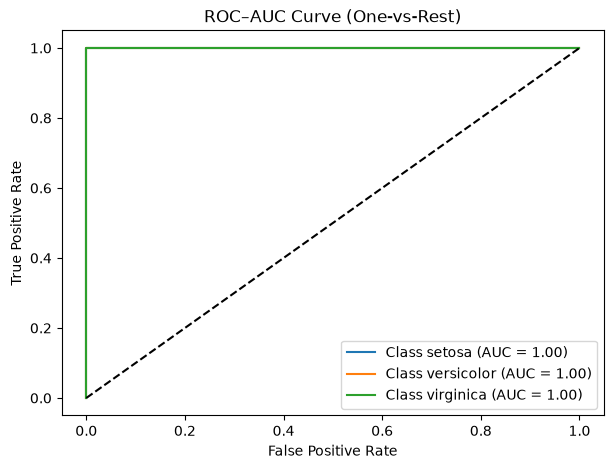

In [12]:
# Binarize labels
y_bin = label_binarize(y, classes=model.classes_)
n_classes = y_bin.shape[1]

# Train OvR model
ovr_model = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42)
)

ovr_model.fit(X_train, label_binarize(y_train, classes=model.classes_))
y_score = ovr_model.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=model.classes_)

# Plot ROC
plt.figure(figsize=(7,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve (One-vs-Rest)")
plt.legend()
plt.show()

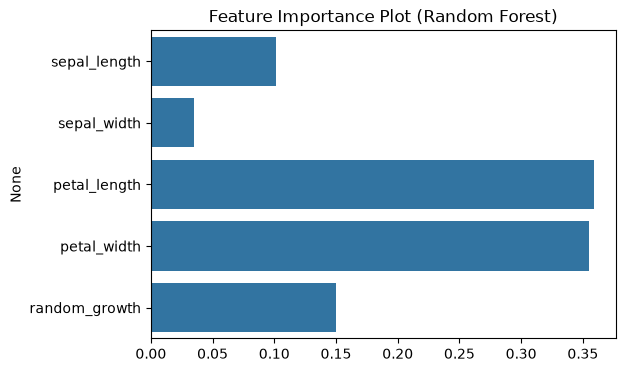

In [13]:
X = df.drop("species", axis=1)
y = df["species"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance Plot (Random Forest)")
plt.show()

### KESIMPULAN

Preprocessing data merupakan tahap penting untuk memastikan data berada dalam kondisi yang layak digunakan. Penanganan missing value dilakukan dengan cara menghapus data atau mengisi nilai yang kosong menggunakan metode statistik seperti mean, median, dan mode. Selain itu, outliers perlu dideteksi dan ditangani agar tidak mempengaruhi distribusi data secara signifikan, salah satunya menggunakan metode IQR.
Visualisasi data digunakan untuk membantu memahami karakteristik data secara lebih jelas. Melalui berbagai grafik seperti histogram, bar chart, scatter plot, dan heatmap, pola distribusi, perbandingan kategori, serta hubungan antar variabel dapat diamati dengan lebih mudah. Visualisasi juga berperan dalam evaluasi model, misalnya melalui confusion matrix dan ROC curve.
Secara keseluruhan, data yang telah melalui proses preprocessing dan divisualisasikan dengan baik akan menghasilkan analisis yang lebih akurat dan dapat mendukung pengambilan keputusan secara lebih tepat.